In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor, BaggingRegressor, StackingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.initializers import GlorotUniform, HeNormal

# Reading CSV File
data = pd.read_excel('10. Final data for research article.xlsx')

# Columns to exclude
columns_to_exclude = ['Chainage','Formation','RMC']

# Preprocessing: Exclude specified columns
X = data.drop(['PRnet'] + columns_to_exclude, axis=1)
Y = data['PRnet']

# Label encoding for categorical columns
label_encoder = LabelEncoder()
for col in ['Lithology', 'Weathering', 'Rock Strength']:
    X[col] = label_encoder.fit_transform(X[col])

# Split the data into training and test sets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Data Standardization
scaler = RobustScaler()
scaler.fit(X_train)  # Fit on the training data
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define models
models = {
    'Decision Tree': DecisionTreeRegressor(criterion='absolute_error', max_depth=10, min_samples_leaf=6, min_samples_split=2, splitter='best'),
    'SVR': SVR(C=50.0, gamma='scale', kernel='rbf'),
    'KNN': KNeighborsRegressor(n_neighbors=5, p=1, weights='distance', algorithm='auto'),
    'Bagging': BaggingRegressor(bootstrap=True, bootstrap_features=False, max_features=1.0, max_samples=0.5, n_estimators=100),
    'Random Forest': RandomForestRegressor(random_state=42, max_depth=30, max_features='log2', min_samples_leaf=1, min_samples_split=5, n_estimators=200),
    'XGBoost': XGBRegressor(colsample_bytree=1, gamma=5, learning_rate=0.1, max_depth=7, n_estimators=100, subsample=0.8),
    'Stacking': StackingRegressor(
        estimators=[
            ('DT', DecisionTreeRegressor(criterion='absolute_error', max_depth=10, min_samples_leaf=6, min_samples_split=2, splitter='best')),
            ('SVR', SVR(C=50.0, gamma='scale', kernel='rbf')),
            ('KNN', KNeighborsRegressor(n_neighbors=5, p=1, weights='distance', algorithm='auto')),
            ('Bagging', BaggingRegressor(bootstrap=True, bootstrap_features=False, max_features=1.0, max_samples=0.5, n_estimators=100)),
            ('RF', RandomForestRegressor(random_state=42, max_depth=30, max_features='log2', min_samples_leaf=1, min_samples_split=5, n_estimators=200)),
            ('XGBoost', XGBRegressor(colsample_bytree=1, gamma=5, learning_rate=0.1, max_depth=7, n_estimators=100, subsample=0.8)),
        ],
        final_estimator=RandomForestRegressor(random_state=42, max_depth=30, max_features='log2', min_samples_leaf=1, min_samples_split=5, n_estimators=200)
    )
}


# Function to create and compile the optimal ANN model
def create_optimal_model():
    model = Sequential([
        Dense(units=352, activation='relu', kernel_initializer='glorot_uniform', input_shape=(X_train.shape[1],)),
        Dense(units=1, activation='relu', kernel_initializer='he_normal')
    ])
    adam_optimizer = Adam(learning_rate=0.001)
    model.compile(optimizer=adam_optimizer,
                  loss='mean_absolute_error',  # Use Mean Absolute Error as the loss function
                  metrics=['mean_absolute_error', 'mean_squared_error'])
    return model



# Add ANN model separately since it needs special treatment
models['ANN'] = create_optimal_model()

# Evaluation metrics dictionary
metrics_dict = {}

# Train, predict, and evaluate each model
for name, model in models.items():
    if name == 'ANN':
        # Train ANN
        early_stopping = EarlyStopping(monitor='val_loss', patience=10)
        model.fit(X_train_scaled, Y_train, epochs=100, batch_size=32, validation_split=0.2, callbacks=[early_stopping], verbose=0)
        Y_train_pred = model.predict(X_train_scaled).flatten()
        Y_test_pred = model.predict(X_test_scaled).flatten()
    else:
        # Train non-ANN models
        model.fit(X_train_scaled, Y_train)
        Y_train_pred = model.predict(X_train_scaled)
        Y_test_pred = model.predict(X_test_scaled)

    # Train metrics
    r2_train = r2_score(Y_train, Y_train_pred)
    mae_train = mean_absolute_error(Y_train, Y_train_pred)
    mse_train = mean_squared_error(Y_train, Y_train_pred)
    rmse_train = np.sqrt(mse_train)
    mape_train = np.mean(np.abs((Y_train - Y_train_pred) / Y_train)) * 100

    # Test metrics
    r2_test = r2_score(Y_test, Y_test_pred)
    mae_test = mean_absolute_error(Y_test, Y_test_pred)
    mse_test = mean_squared_error(Y_test, Y_test_pred)
    rmse_test = np.sqrt(mse_test)
    mape_test = np.mean(np.abs((Y_test - Y_test_pred) / Y_test)) * 100

    # Store metrics for train and test
    metrics_dict[name] = {
        'R2_Train': r2_train, 'MAE_Train': mae_train, 'RMSE_Train': rmse_train, 'MAPE_Train': mape_train,
        'R2_Test': r2_test, 'MAE_Test': mae_test, 'RMSE_Test': rmse_test, 'MAPE_Test': mape_test
    }

# Create a DataFrame to hold all metrics for comparison
metrics_df = pd.DataFrame(metrics_dict).T
metrics_df = metrics_df.round(3)

# Display the metrics table
print(metrics_df)

54/54 [==============================] - 0s 730us/step
               R2_Train  MAE_Train  RMSE_Train  MAPE_Train  R2_Test  MAE_Test  \
Decision Tree     0.926      2.059       4.210       3.204    0.926     2.439   
SVR               0.927      2.018       4.174       3.039    0.936     2.187   
KNN               1.000      0.001       0.028       0.001    0.913     2.928   
Bagging           0.971      1.499       2.652       2.309    0.937     2.326   
Random Forest     0.980      1.292       2.196       2.000    0.936     2.397   
XGBoost           0.972      1.654       2.610       2.477    0.938     2.398   
Stacking          0.976      1.419       2.385       2.151    0.937     2.301   
ANN               0.912      2.232       4.590       3.404    0.933     2.165   

               RMSE_Test  MAPE_Test  
Decision Tree      4.294      3.859  
SVR                3.996      3.410  
KNN                4.647      4.575  
Bagging            3.964      3.627  
Random Forest      3.981 

In [2]:
# Save the DataFrame to an Excel file
metrics_df.to_excel('evaluation_metrics.xlsx')

print("Results saved to evaluation_metrics.xlsx")

Results saved to evaluation_metrics.xlsx


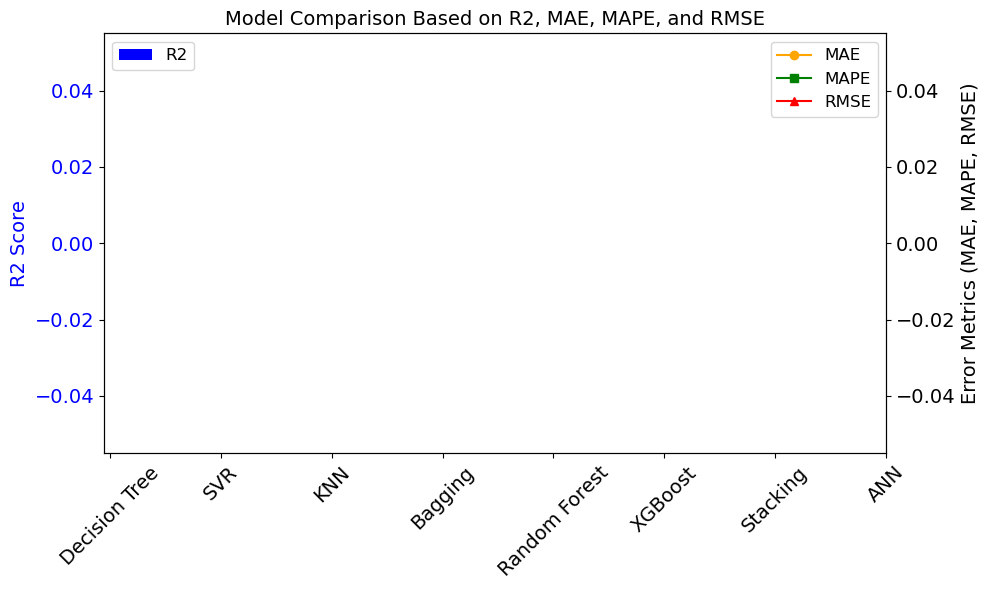

C:\Users\tekbk\AppData\Local\Temp\ipykernel_15008\4102071790.py:35: FutureWarning: The behavior of Series.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  best_model = metrics_df['R2'].idxmax()


KeyError: nan

In [3]:
import matplotlib.pyplot as plt

# Create a DataFrame to hold all metrics for comparison
metrics_df = pd.DataFrame(metrics_dict, index=['R2', 'MAE', 'MSE', 'RMSE', 'RRMSE', 'MAPE', 'MRE', 'VAF']).T
metrics_df = metrics_df.round(3)

# Plot R2 with bar plot and MAE, MAPE, RMSE with twin y-axis using line plot
fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar plot for R2 score with reduced bar width
bar_width = 0.2  # Adjust this value to change the width of the bars
ax1.bar(metrics_df.index, metrics_df['R2'], color='blue', width=bar_width, label='R2')
ax1.set_ylabel('R2 Score', color='blue', fontsize=14)
ax1.set_title('Model Comparison Based on R2, MAE, MAPE, and RMSE', fontsize=14)
ax1.tick_params(axis='y', labelcolor='blue', labelsize=14)
ax1.set_xticks(range(len(metrics_df.index)))  # Ensure x-ticks are at the correct positions
ax1.set_xticklabels(metrics_df.index, rotation=45, color='black', fontsize=14)

# Create a twin y-axis for MAE, MAPE, and RMSE
ax2 = ax1.twinx()
ax2.plot(metrics_df.index, metrics_df['MAE'], color='orange', marker='o', label='MAE')
ax2.plot(metrics_df.index, metrics_df['MAPE'], color='green', marker='s', label='MAPE')
ax2.plot(metrics_df.index, metrics_df['RMSE'], color='red', marker='^', label='RMSE')
ax2.set_ylabel('Error Metrics (MAE, MAPE, RMSE)', fontsize=14)
ax2.tick_params(axis='y', labelsize=14)

# Adding legends for both axes
ax1.legend(loc='upper left', fontsize=12)
ax2.legend(loc='upper right', fontsize=12)

plt.tight_layout()
plt.show()

# Identify and print the best model based on R2 score
best_model = metrics_df['R2'].idxmax()
print(f'The best model based on R2 score is: {best_model} with R2 score of {metrics_df.loc[best_model, "R2"]}')


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.initializers import GlorotUniform, HeNormal

# Evaluation metrics dictionary
metrics_dict = {}

# Train, predict, and evaluate each model
for name, model in models.items():
    if name == 'ANN':
        # Train ANN
        early_stopping = EarlyStopping(monitor='val_loss', patience=10)
        model.fit(X_train_scaled, Y_train, epochs=100, batch_size=32, validation_split=0.2, callbacks=[early_stopping], verbose=0)
        Y_test_pred = model.predict(X_test_scaled).flatten()
    else:
        # Train non-ANN models
        model.fit(X_train_scaled, Y_train)
        Y_test_pred = model.predict(X_test_scaled)

    # Calculate evaluation metrics
    r2 = r2_score(Y_test, Y_test_pred)
    mae = mean_absolute_error(Y_test, Y_test_pred)
    mse = mean_squared_error(Y_test, Y_test_pred)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((Y_test - Y_test_pred) / Y_test)) * 100

    # Store the metrics
    metrics_dict[name] = [r2, mae, mse, rmse, mape]

# Create a DataFrame to hold all metrics for comparison
metrics_df = pd.DataFrame(metrics_dict, index=['R2', 'MAE', 'MSE', 'RMSE', 'MAPE']).T
metrics_df = metrics_df.round(3)

# Identify the best model based on R2 score and MAPE
best_r2_model = metrics_df['R2'].idxmax()
best_mape_model = metrics_df['MAPE'].idxmin()

print(f'The best model based on R2 score is: {best_r2_model} with R2 score of {metrics_df.loc[best_r2_model, "R2"]}')
print(f'The best model based on MAPE is: {best_mape_model} with MAPE of {metrics_df.loc[best_mape_model, "MAPE"]}')

# If you need a combined best model based on both metrics, you can create a custom ranking method
# For simplicity, here we just output the individual best models based on each metric.


In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, RobustScaler

# Define function to handle label encoding with unseen labels
def safe_label_encode(df, columns, encoder):
    for col in columns:
        if col in df.columns:
            # Create a copy of the original column to check for unseen labels
            original_col = df[col].copy()
            # Encode using the existing encoder
            df[col] = encoder.transform(df[col])
            # Find unseen labels
            unseen_labels = set(original_col) - set(encoder.classes_)
            if unseen_labels:
                print(f"Warning: Unseen labels found in column '{col}': {unseen_labels}")
                # Handle unseen labels if necessary (e.g., by mapping them to a default value or excluding them)
    return df

# Load the new data
new_data = pd.read_excel('hello.xlsx')

# Preprocess the new data
new_data = new_data.drop(columns=columns_to_exclude)

# Apply label encoding with handling for unseen labels
new_data = safe_label_encode(new_data, ['Lithology', 'Weathering', 'Rock Strength'], label_encoder)

# Standardize the new data using the same scaler fitted on the training data
new_data_scaled = scaler.transform(new_data)

# Load the trained SVR model
svr_model = models['SVR']

# Predict using the trained SVR model
svr_predictions = svr_model.predict(new_data_scaled)

# Save the predictions to an Excel file
predictions_df = pd.DataFrame({
    'Predicted_PRnet': svr_predictions
})

predictions_df.to_excel('svr_predictions.xlsx', index=False)

print("SVR predictions saved to 'svr_predictions.xlsx'.")


In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.svm import SVR

# Load the new data
new_data = pd.read_excel('hello.xlsx')

# Preprocess the new data
# Assuming columns_to_exclude and label_encoder are already defined
new_data = new_data.drop(columns=columns_to_exclude)

# Apply label encoding to categorical columns (make sure to use the same label encoder used for training)
for col in ['Lithology', 'Weathering', 'Rock Strength']:
    if col in new_data.columns:
        new_data[col] = label_encoder.transform(new_data[col])

# Standardize the new data using the same scaler fitted on the training data
new_data_scaled = scaler.transform(new_data)

# Load the trained SVR model
# Assuming you have already trained and stored the SVR model in `models['SVR']`
svr_model = models['SVR']

# Predict using the trained SVR model
svr_predictions = svr_model.predict(new_data_scaled)

# Save the predictions to an Excel file
predictions_df = pd.DataFrame({
    'Predicted_PRnet': svr_predictions
})

predictions_df.to_excel('svr_predictions.xlsx', index=False)

print("SVR predictions saved to 'svr_predictions.xlsx'.")
